In [2]:
# Importación de librerías
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv("student_lifestyle_performance_dataset.csv")
df.head()

,Age,Branch,Study_Hours_per_Day,Sleep_Hours,Screen_Time_Hours,Gym_Hours_per_Week,Diet_Type,Attendance_Percentage,Stress_Level_1_to_10,Residence,Internal_Marks,CGPA
0,23,ECE,4.14,6.84,9.23,2.67,Non-Veg,81.24,4.93,Hosteller,65.86,7.52
1,20,Civil,5.97,5.52,3.09,15.61,Veg,90.55,6.96,Day Scholar,62.52,7.21
2,24,Electrical,3.19,3.39,5.02,2.52,Veg,69.40,7.38,Hosteller,40.11,4.84
3,21,CSE,4.77,6.44,9.21,0.00,Non-Veg,80.79,5.84,Day Scholar,61.25,6.74
4,23,Civil,5.42,6.54,4.76,9.93,Veg,82.63,6.67,Day Scholar,64.54,7.77


In [4]:
#Usamos OneHotEncoder para convertir las variables categoricas en variables numericas
#Y despues procesarlas para ver si son utiles
categorical_cols = ["Branch", "Diet_Type", "Residence"]
numerical_cols = [col for col in df.columns if col not in categorical_cols]
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_data = encoder.fit_transform(df[categorical_cols])
column_transformer = ColumnTransformer(transformers=[('cat', encoder, categorical_cols)],remainder='passthrough')
X_encoded = column_transformer.fit_transform(df)
encoded_col_names = column_transformer.named_transformers_['cat'].get_feature_names_out(categorical_cols)
final_columns = list(encoded_col_names) + numerical_cols
df_encoded = pd.DataFrame(X_encoded, columns=final_columns)
print(df_encoded.head())

   Branch_Civil  Branch_ECE  Branch_Electrical  Branch_IT  Branch_Mechanical  \
0           0.0         1.0                0.0        0.0                0.0   
1           1.0         0.0                0.0        0.0                0.0   
2           0.0         0.0                1.0        0.0                0.0   
3           0.0         0.0                0.0        0.0                0.0   
4           1.0         0.0                0.0        0.0                0.0   

   Diet_Type_Veg  Residence_Hosteller   Age  Study_Hours_per_Day  Sleep_Hours  \
0            0.0                  1.0  23.0                 4.14         6.84   
1            1.0                  0.0  20.0                 5.97         5.52   
2            1.0                  1.0  24.0                 3.19         3.39   
3            0.0                  0.0  21.0                 4.77         6.44   
4            1.0                  0.0  23.0                 5.42         6.54   

   Screen_Time_Hours  Gym_Hours_

In [5]:
#Seleccionamos las variables que creemos que pueden tener una relacion importante con la variable objetivo y las separamos en X e y
var_cols = ["Branch_Civil", "Branch_ECE", "Branch_Electrical", "Branch_IT", "Branch_Mechanical", "Diet_Type_Veg", "Residence_Hosteller", "Age", "Study_Hours_per_Day", "Sleep_Hours", "Screen_Time_Hours", "Gym_Hours_per_Week", "Attendance_Percentage", "Stress_Level_1_to_10","CGPA"]
X = df_encoded[var_cols]
y = df_encoded["Internal_Marks"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# 1. Instanciamos el modelo
tree_reg = DecisionTreeRegressor(max_depth=4, random_state=42)

# 2. Entrenamos con datos de entrenamiento
tree_reg.fit(X_train, y_train)

# 3. Hacemos predicciones
y_pred = tree_reg.predict(X_test)

# 4. Evaluamos
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(y_test - y_pred))

print(f"Error cuadrático medio (MSE): {mse:.2f}")
print(f"Coeficiente de determinación (R²): {r2:.4f}")
print(f"Raíz del error cuadrático medio (RMSE): {rmse:.2f}")
print(f"Error absoluto medio (MAE): {mae:.2f}")

Error cuadrático medio (MSE): 31.88
Coeficiente de determinación (R²): 0.7283
Raíz del error cuadrático medio (RMSE): 5.65
Error absoluto medio (MAE): 4.53


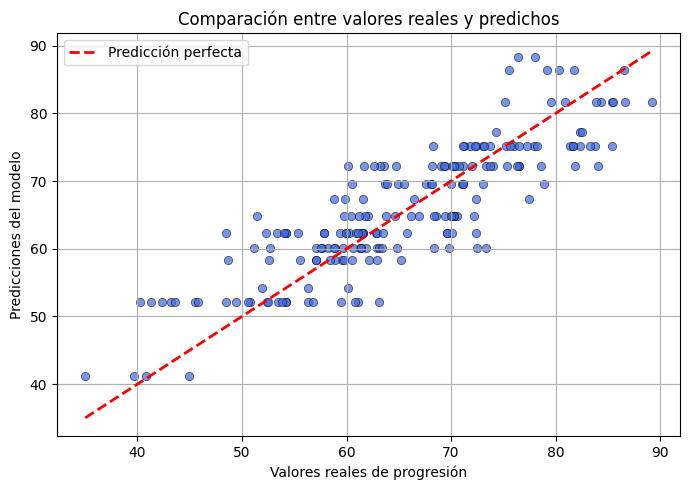

In [8]:
# Gráfica de dispersión: y real vs y predicho
plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_test, y=y_pred, color='royalblue', edgecolor='black', alpha=0.7)

# Línea de referencia perfecta
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Predicción perfecta')

plt.xlabel('Valores reales de progresión')
plt.ylabel('Predicciones del modelo')
plt.title('Comparación entre valores reales y predichos')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
# 1. Definimos un modelo base
model_base = DecisionTreeRegressor(random_state=42) # No especificamos parámetros

# 2. Definimos el grid de búsqueda de hiperparámetros
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5]
}

# 3. Configurar GridSearch junto con los parámetros de la validación cruzada
grid = GridSearchCV(estimator=model_base, # modelo base
                    param_grid=param_grid, # grid de hiperparámetros
                    cv=5, # numero k fold 
                    scoring='r2', # métrica de referencia
                    n_jobs=1,  # usa un solo núcleo al procesar
                    return_train_score=True)

# 4. Entrenar el GridSearch con datos de entrenamiento (la evaluación vendrá posteriormente)
grid.fit(X_train, y_train)

# 5. Observamos los mejores parámetros que encontró
print('Mejores parámetros: ')
for key, value in grid.best_params_.items(): # best_params es un diccionario
    print(f'Mejor valor de {key}: {value}')
print(f"Mejor score promedio (R2 CV): {grid.best_score_:.4f}")

Mejores parámetros: 
Mejor valor de max_depth: 3
Mejor valor de min_samples_leaf: 1
Mejor valor de min_samples_split: 2
Mejor score promedio (R2 CV): 0.7033


In [10]:
tree_reg = DecisionTreeRegressor(max_depth=3, min_samples_split=2, min_samples_leaf=1, random_state=42)
tree_reg.fit(X_train, y_train)
y_pred = tree_reg.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"R2 del modelo con mejores hiperparámetros: {r2:.4f}")

R2 del modelo con mejores hiperparámetros: 0.7295


In [11]:
# 1. Instanciamos el modelo
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    oob_score=True,
    random_state=42,
    n_jobs=1
)

# 2. Entrenamos
rf.fit(X_train, y_train)

# 3. Predicciones sobre el conjunto de prueba
y_pred_rf = rf.predict(X_test)

# 4. Evaluación
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest - MSE: {mse_rf:.2f}")
print(f"Random Forest - RMSE: {np.sqrt(mse_rf):.2f}")
print(f"Random Forest - R2: {r2_rf:.4f}")
print(f"Random Forest - OOB Score (estimación): {rf.oob_score_:.4f}")

Random Forest - MSE: 30.58
Random Forest - RMSE: 5.53
Random Forest - R2: 0.7393
Random Forest - OOB Score (estimación): 0.7254


In [12]:
# 1. Instanciamos el módelo
gbr = GradientBoostingRegressor(
    n_estimators=100,         # Número de árboles
    learning_rate=0.1,        # Tasa de aprendizaje (gamma)
    max_depth=3,              # Profundidad de cada árbol base
    random_state=42
)

# 2. Entrenamiento sobre conjunto de entrenamiento
gbr.fit(X_train, y_train)

# 3. Predicciones sobre conjunto de prueba
y_pred_gbr = gbr.predict(X_test)

# 4. Evaluación
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)

# Mostrar resultados
print(f"Gradient Boosting - MSE: {mse_gbr:.2f}")
print(f"Gradient Boosting - R²: {r2_gbr:.4f}")

Gradient Boosting - MSE: 30.76
Gradient Boosting - R²: 0.7378
